In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_37.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_45.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_25.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_40.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/phanton60_left_8_66.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/phanton60_left_8_69.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/Phanton60_right_48.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/phanton60_left_8_78.png
/kaggle/input/spectrogram-image-classification/dataset_spetrogram/valid/Phanton4/phanton60_left_8_73.png
/kaggle/input/spectrogram-image-classification/dataset_spetr

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
PyTorch version 2.3.1
Torchvision version 0.18.1
Numpy version 1.26.4
Pandas version 2.2.2


In [2]:
class SpectrogramImagesDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [3]:
dataset = SpectrogramImagesDataset(
    data_dir=r'D:\FYP_Drone_Swarms_Detection\dataset_extended\sorted_dataset\train'
)

In [4]:
len(dataset)

1936

0


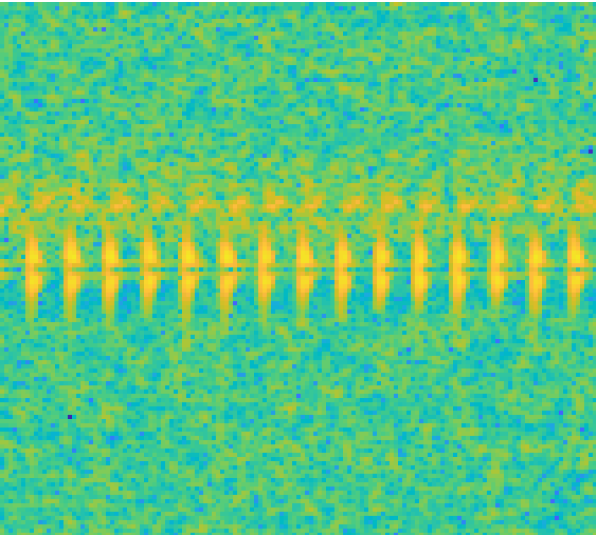

In [5]:
image, label = dataset[125]
print(label)
image

In [7]:
# Get a dictionary associating target values with folder names
data_dir = r'D:\FYP_Drone_Swarms_Detection\dataset_extended\sorted_dataset\train'
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'Environment', 1: 'F185_drone', 2: 'Mavic2_drone', 3: 'Phantom4_drone'}


In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

data_dir = r'D:\FYP_Drone_Swarms_Detection\dataset_extended\sorted_dataset\train'
dataset = SpectrogramImagesDataset(data_dir, transform)

In [9]:
image, label = dataset[100]
image.shape

torch.Size([3, 128, 128])

In [10]:
# iterate over dataset
for image, label in dataset:
    break

In [11]:
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [12]:
for images, labels in dataloader:
    break

In [13]:
images.shape, labels.shape

(torch.Size([8, 3, 128, 128]), torch.Size([8]))

In [14]:
labels

tensor([3, 0, 0, 1, 0, 2, 0, 1])

In [15]:
class SimpleSpectrogramImagesClassifer(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleSpectrogramImagesClassifer, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280
        # Make a classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(enet_out_size, num_classes)
        )
    
    def forward(self, x):
        # Connect these parts and return the output
        x = self.features(x)
        output = self.classifier(x)
        return output

In [16]:
model = SimpleSpectrogramImagesClassifer(num_classes=4)
print(str(model)[:500])

SimpleSpectrogramImagesClassifer(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups


In [17]:
example_out = model(images)
example_out.shape # [batch_size, num_classes]

torch.Size([8, 4])

In [18]:
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
criterion(example_out, labels)
print(example_out.shape, labels.shape)

torch.Size([8, 4]) torch.Size([8])


In [20]:
from torchvision import transforms

# Define transformations with data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.RandomHorizontalFlip(),  # Randomly flip the images horizontally
    transforms.RandomRotation(10),  # Randomly rotate the images by up to 10 degrees
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),  # Randomly crop and resize
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize images (example values)
])

# Use a simpler transform for validation and test datasets (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [21]:

# Correct folder paths
train_folder = r'C:\Users\user\Downloads\test\dataset_extended STFT\Train'
valid_folder = r'C:\Users\user\Downloads\test\dataset_extended STFT\Test'
test_folder = r'C:\Users\user\Downloads\test\dataset_extended STFT\Test'


train_dataset = SpectrogramImagesDataset(train_folder, transform=train_transform)
val_dataset = SpectrogramImagesDataset(valid_folder, transform=val_test_transform)
test_dataset = SpectrogramImagesDataset(test_folder, transform=val_test_transform)


In [22]:
train_dataset = SpectrogramImagesDataset(train_folder, transform=train_transform)
val_dataset = SpectrogramImagesDataset(valid_folder, transform=val_test_transform)
test_dataset = SpectrogramImagesDataset(test_folder, transform=val_test_transform)


In [23]:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # L2 regularization


In [24]:


# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  # Use test_dataset for the test loader


In [25]:


num_epochs =20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SimpleSpectrogramImagesClassifer(num_classes=4)
model.to(device)

criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in tqdm(train_loader, desc='Training loop'):
        # Move inputs and labels to the device
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * labels.size(0)
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation phase
    model.eval()
    running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation loop'):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            
            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    val_loss = running_loss / len(val_loader.dataset)
    val_accuracy = correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")

# Testing phase (after training is complete)
model.eval()
correct_test = 0
total_test = 0
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing loop'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        
        # Calculate testing accuracy
        _, predicted = torch.max(outputs, 1)
        correct_test += (predicted == labels).sum().item()
        total_test += labels.size(0)

test_accuracy = correct_test / total_test
print(f"Test Accuracy: {test_accuracy:.4f}")


Training loop:   0%|          | 0/66 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/20 - Train loss: 1.3924, Validation loss: 1.4014
Train Accuracy: 0.2567, Validation Accuracy: 0.3057


Training loop:   0%|          | 0/66 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training loop:   0%|          | 0/66 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 12/20 - Train loss: 1.3960, Validation loss: 1.4013
Train Accuracy: 0.2677, Validation Accuracy: 0.3248


Training loop:   0%|          | 0/66 [00:00<?, ?it/s]

KeyboardInterrupt: 

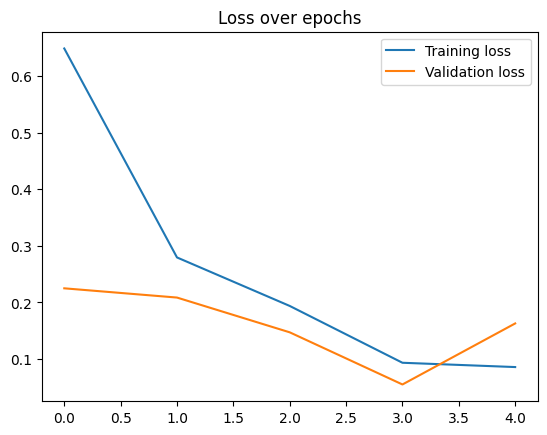

In [24]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

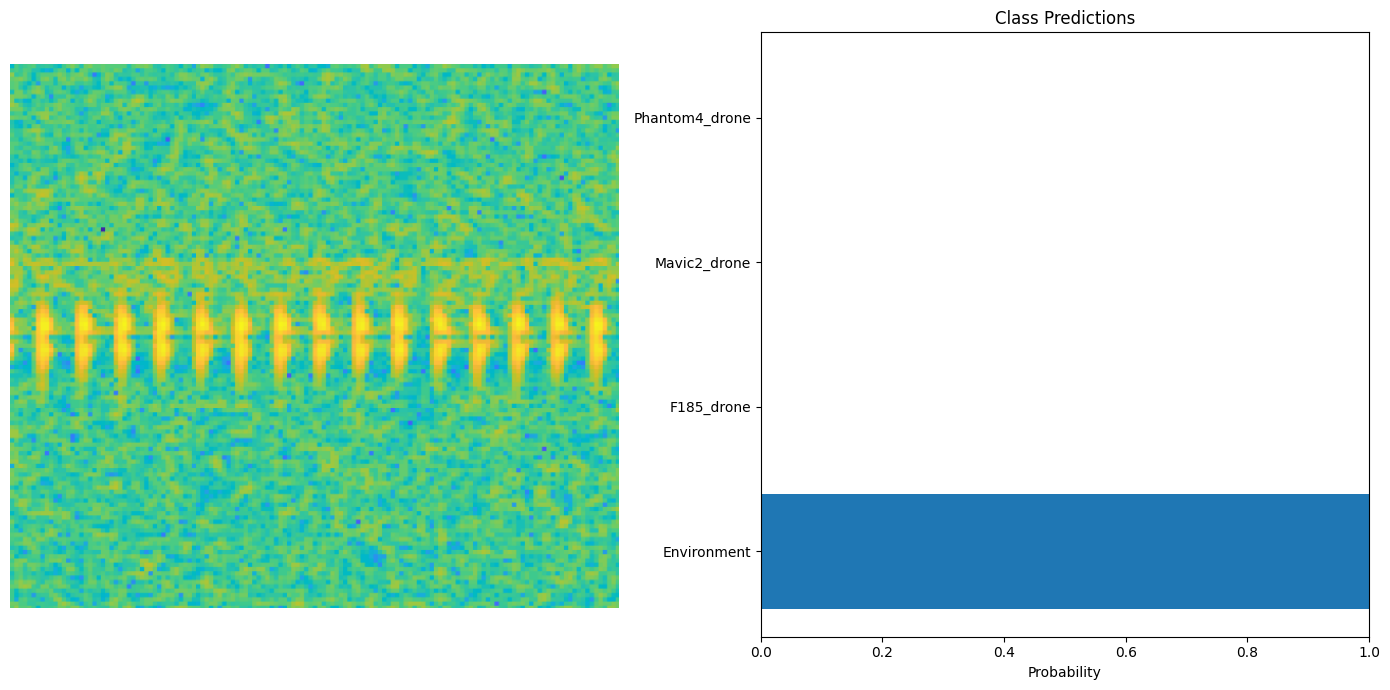

In [29]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
    
    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    
    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example usage
test_image = r"D:\FYP_Drone_Swarms_Detection\dataset_extended\sorted_dataset\test\Environment\Environment_img_0026.png"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = dataset.classes 
visualize_predictions(original_image, probabilities, class_names)

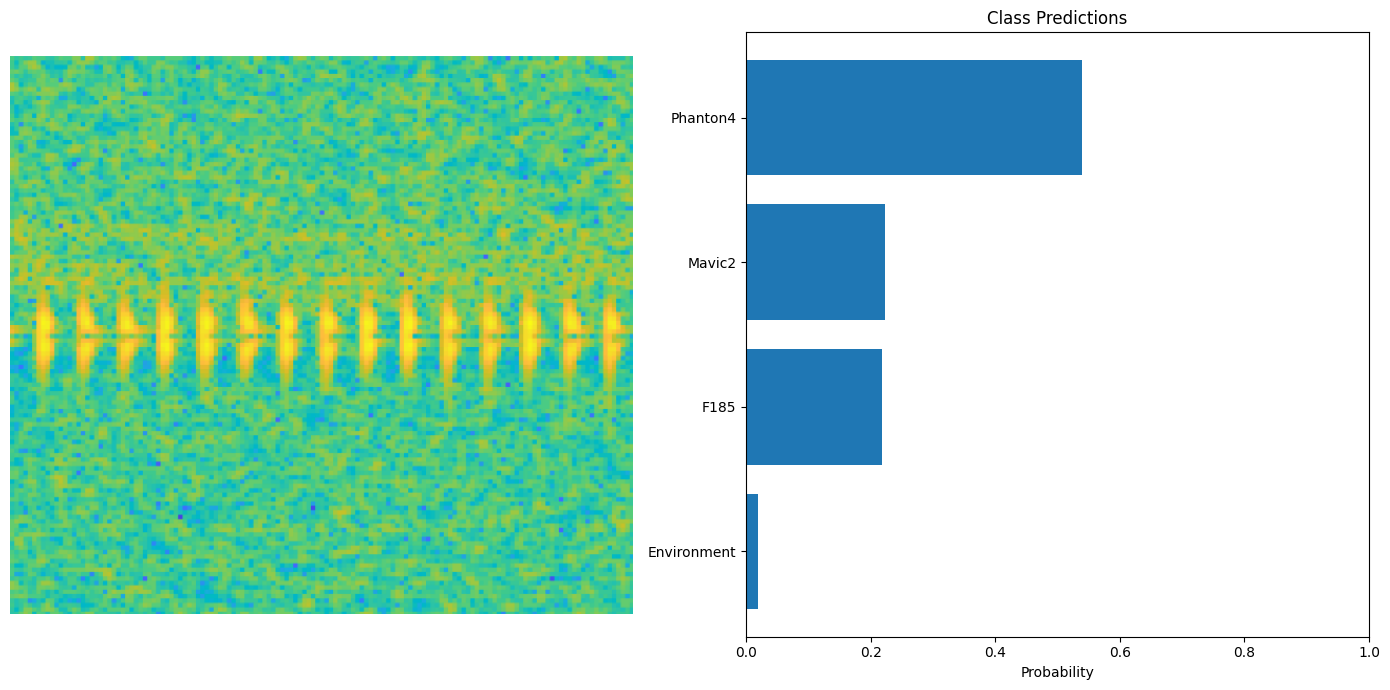

In [27]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
    
    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    
    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example usage
test_image = "D:/Drone-Swarm-Detection-with-AWR2243/Our data/Radar_Data/dataset_spetrogram/test/Mavic2/Waruna_up_forward_42.png"
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = dataset.classes 
visualize_predictions(original_image, probabilities, class_names)